(1407328, 6) Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='object')
(3774, 6) Index(['date', 'close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
VADER correlation: {'pearson_r': np.float64(-0.0015263845654809583), 'pearson_p': np.float64(0.9426216559375837), 'spearman_r': np.float64(0.022112363091346714), 'spearman_p': np.float64(0.2970344716688907)}
TextBlob correlation: {'pearson_r': np.float64(-0.019444381937073256), 'pearson_p': np.float64(0.35915985873220935), 'spearman_r': np.float64(-0.007796775758053168), 'spearman_p': np.float64(0.713130662744453)}


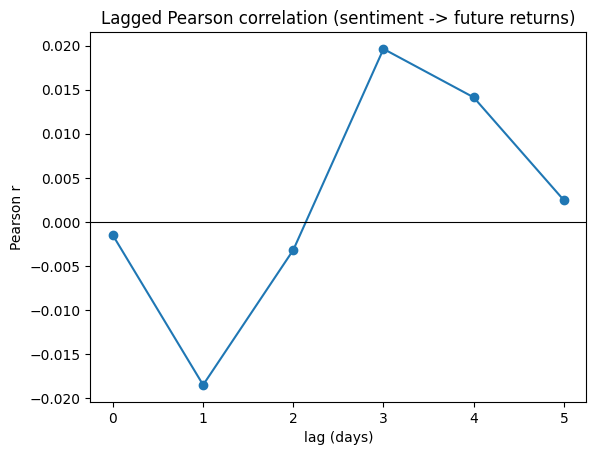

In [9]:
import pandas as pd
import numpy as np

# ------------------------------
# Load CSV files
# ------------------------------
news_df = pd.read_csv("news.csv", parse_dates=["date"])
price_df = pd.read_csv("price_data.csv", parse_dates=["Date"])

# Normalize column names
news_df.rename(columns={'date': 'date', 'headline': 'headline'}, inplace=True)
price_df.rename(columns={'Date': 'date', 'Close': 'close'}, inplace=True)

print(news_df.shape, news_df.columns)
print(price_df.shape, price_df.columns)

# Ensure datetime format
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')
price_df['date'] = pd.to_datetime(price_df['date'], errors='coerce')

# Convert to daily granularity
news_df['day'] = news_df['date'].dt.date
price_df['day'] = price_df['date'].dt.date

# Drop invalid dates
news_df = news_df.dropna(subset=['day'])
price_df = price_df.dropna(subset=['day'])

# ------------------------------
# TEXTBLOB SENTIMENT
# ------------------------------
from textblob import TextBlob

def textblob_polarity(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return np.nan

news_df['tb_polarity'] = news_df['headline'].apply(textblob_polarity)

# ------------------------------
# VADER SENTIMENT
# ------------------------------
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

try:
    sia = SentimentIntensityAnalyzer()
except:
    nltk.download('vader_lexicon')
    sia = SentimentIntensityAnalyzer()

def vader_score(text):
    try:
        return sia.polarity_scores(str(text))['compound']
    except:
        return np.nan

news_df['vader_polarity'] = news_df['headline'].apply(vader_score)

# ------------------------------
# Daily sentiment aggregation
# ------------------------------
daily_sent = news_df.groupby('day').agg(
    tb_mean=('tb_polarity', 'mean'),
    tb_median=('tb_polarity', 'median'),
    vader_mean=('vader_polarity', 'mean'),
    article_count=('headline', 'count')
).reset_index().sort_values('day')

daily_sent['day'] = pd.to_datetime(daily_sent['day'])
daily_sent = daily_sent.set_index('day')
daily_sent.head()

# ------------------------------
# Price data preparation
# ------------------------------
price_df = price_df.sort_values('day').drop_duplicates('day')
price_df = price_df.set_index(pd.to_datetime(price_df['day']))

price_df['close'] = price_df['close'].astype(float)
price_df = price_df.sort_index()

# Create daily returns
price_df['return'] = price_df['close'].pct_change()
daily_returns = price_df[['close', 'return']].copy()

# ------------------------------
# Combine price + sentiment
# ------------------------------
df_combined = daily_returns.join(daily_sent, how='left')
df_combined = df_combined.sort_index()
df_combined.head()

# ------------------------------
# CORRELATION DATAFRAME (clean)
# ------------------------------
df_corr = df_combined[['return', 'tb_mean', 'vader_mean', 'article_count']]

# Drop rows where return or vader_mean are missing
df_corr = df_corr.dropna(subset=['return', 'vader_mean'])

df_corr.head()

from scipy import stats

def corr_and_p(x, y):
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    return {'pearson_r':pearson_r, 'pearson_p':pearson_p, 'spearman_r':spearman_r, 'spearman_p':spearman_p}

# example between vader_mean and return
series = df_corr.dropna(subset=['vader_mean','return'])
res_vader = corr_and_p(series['vader_mean'], series['return'])
res_tb = corr_and_p(df_corr.dropna(subset=['tb_mean'])['tb_mean'], df_corr.dropna(subset=['tb_mean'])['return'])

print("VADER correlation:", res_vader)
print("TextBlob correlation:", res_tb)

import pandas as pd
lags = range(0,6)
corr_results = []

for lag in lags:
    # sentiment at day t vs return at day t+lag
    temp = df_combined[['vader_mean','return']].copy()
    temp['return_future'] = temp['return'].shift(-lag)
    temp2 = temp.dropna(subset=['vader_mean','return_future'])
    if len(temp2) > 5:
        r, p = stats.pearsonr(temp2['vader_mean'], temp2['return_future'])
    else:
        r, p = np.nan, np.nan
    corr_results.append({'lag':lag, 'pearson_r':r, 'pearson_p':p, 'n':len(temp2)})

pd.DataFrame(corr_results)
import matplotlib.pyplot as plt
res_df = pd.DataFrame(corr_results).set_index('lag')
res_df['pearson_r'].plot(marker='o', title='Lagged Pearson correlation (sentiment -> future returns)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('lag (days)')
plt.ylabel('Pearson r')
plt.show()


import statsmodels.api as sm

# regress return on today sentiment and previous return (AR1)
temp = df_combined[['return','vader_mean']].dropna()
temp['return_lag1'] = temp['return'].shift(1)
temp = temp.dropna()

X = temp[['vader_mean','return_lag1']]
X = sm.add_constant(X)
y = temp['return']

model = sm.OLS(y, X).fit()
print(model.summary())


import seaborn as sns

sns.regplot(data=df_corr, x='vader_mean', y='return', scatter_kws={'s':10}, line_kws={'color':'red'})
plt.title('VADER sentiment vs Daily Return')
plt.xlabel('VADER mean sentiment (daily)')
plt.ylabel('Daily return')
plt.show()
fig, ax1 = plt.subplots(figsize=(14,5))
ax1.plot(df_combined.index, df_combined['close'], label='Close', color='black')
ax2 = ax1.twinx()
ax2.plot(df_combined.index, df_combined['vader_mean'], label='VADER mean', color='orange', alpha=0.6)
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.title('Price and Daily Mean VADER Sentiment')
plt.show()
